In [13]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import json
import dit
import subprocess
from dit import Distribution
from dit.shannon import mutual_information as mi
from dit.shannon import entropy as H
from emergence.calc.dit import DitDistCalc
from emergence.micalc import MutualInfo
from emergence.utils.jvm import JVM
import ptitprince as pt

In [23]:
N = 10  # number of runs per value of goodagproportion
path = "gameDumps/platonictendency"
psis = []
groups = []

In [19]:
# Step 1: run all the experiments
for i in range(11):
    goodagproportion = i / 10.0 # to get 0.0, 0.1, 0.2 et
    for j in range(N):
        command = f"go run main.go -goodagproportion={goodagproportion}"
        subprocess.run(command, shell=True)

In [24]:
# pairs
for folder in os.listdir(path):
    for file in os.listdir(f"{path}/{folder}"):
        joint_counts = {}
        total = 0
        with open(f"{path}/{folder}/{file}", 'r') as f:
            data = json.load(f)
            all_agent_uuids = data["agentUUIDS"]
            all_bike_uuids = data["bikeUUIDS"]
            agent_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_agent_uuids)}
            bike_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_bike_uuids)}
            for iteration in data["iterations"]:
                agentBikes = iteration.get("agentBikes")
                agent_ids = list(agentBikes.keys())
                for i in range(len(agent_ids)):
                    for j in range(i+1, len(agent_ids)):
                        a_id, b_id = agent_ids[i], agent_ids[j]
                        a = agent_uuid_to_idx[a_id]
                        b = agent_uuid_to_idx[b_id]
                        bike_a = bike_uuid_to_idx[agentBikes[a_id]]
                        bike_b = bike_uuid_to_idx[agentBikes[b_id]]
                        same_bike = int(bike_a == bike_b)
                        key = (a, b, same_bike)
                        joint_counts[key] = joint_counts.get(key, 0) + 1
                        total += 1

        outcomes = list(joint_counts.keys())
        probs = [joint_counts[o] / total for o in outcomes]

        dist = Distribution(outcomes, probs)
        calc = DitDistCalc(dist, mi)
        psi = calc.psi(q=2)
        psis.append(psi)
        groups.append(f"{folder}")


<Axes: xlabel='Proportion Good Agents', ylabel='Psi'>

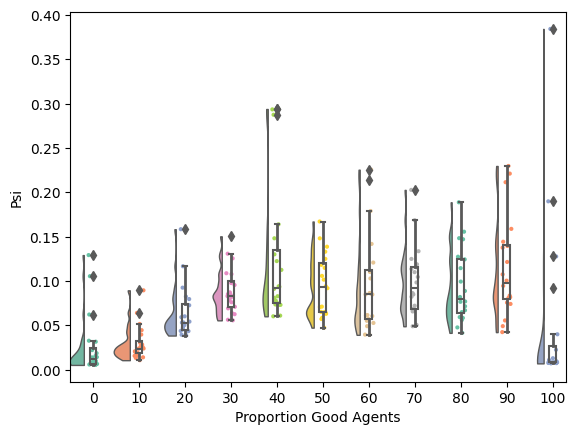

In [26]:
df = pd.DataFrame({
    "Psi": psis,
    "Proportion Good Agents": groups
})

# Convert group labels to integers for correct x-axis ordering
df["Proportion Good Agents"] = df["Proportion Good Agents"].astype(int)
df = df.sort_values("Proportion Good Agents")

pt.RainCloud(x="Proportion Good Agents", y="Psi", data=df, orient="v")


In [27]:
# Step 4: Cleanup
for folder in os.listdir(path):
    for file in os.listdir(f"{path}/{folder}"):
        os.remove(f"{path}/{folder}/{file}")